# RQ1: Hybrid Anonymization + DP-SGD for Emotion Detection
**Research Question**: How effectively does combining anonymization/pseudonymization with DP-SGD mitigate privacy risks in emotion detection models used in mental health chatbots?

## Methodology:
1. Train 4 RoBERTa-base variants:
   - **V0_BASELINE**: Raw text (no privacy)
   - **V1_ANONYM**: Anonymized text only
   - **V2_DP_SGD**: DP-SGD on raw text (ε=8, δ=1e-5)
   - **V3_HYBRID**: DP-SGD on anonymized text (ε=8, δ=1e-5)

2. Evaluate privacy (exact memorization) + utility (F1-macro)
3. Compare hybrid vs standalone effectiveness

In [ ]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
# File paths
RAW_PATH = os.path.join('go_emotions_dataset.csv')
CLEANED_PATH = os.path.join('go_emotions_cleaned.csv')
OUTPUT_DIR = os.path.join('models', 'rq1_variants')
REPORT_DIR = os.path.join('reports', 'rq1')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Load datasets
df_raw = pd.read_csv(RAW_PATH)
df_cleaned = pd.read_csv(CLEANED_PATH)

print(f"Raw: {df_raw.shape} | Cleaned: {df_cleaned.shape}")

Raw: (211225, 31) | Cleaned: (57580, 32)


Prepare Train/Val/Test Splits

In [4]:
from sklearn.model_selection import train_test_split

# Identify emotion columns
meta_cols = {'id', 'text', 'example_very_unclear', 'clean_text', 'neutral'}
emotion_cols = [col for col in df_raw.columns if col not in meta_cols]

print(f"Emotion columns: {len(emotion_cols)}")

Emotion columns: 27


In [5]:
# Merge datasets on ID
df = df_raw.copy()
df = df.merge(df_cleaned[['id', 'clean_text']], on='id', how='inner')

# Stratify by high-emotion texts
df['num_emotions'] = df[emotion_cols].sum(axis=1)

# Use qcut with duplicates='drop' to handle skewed distributions
df['emotion_bin'] = pd.qcut(df['num_emotions'], q=3, duplicates='drop')

# Dynamically rename categories to match expected labels
n_bins = len(df['emotion_bin'].cat.categories)
label_map = {i: label for i, label in enumerate(['low', 'med', 'high'][:n_bins])}
df['emotion_bin'] = df['emotion_bin'].cat.rename_categories(label_map)

print(f"Stratification created {n_bins} bins: {df['emotion_bin'].value_counts().sort_index().to_dict()}")

# 60% train, 20% val, 20% test
train_idx, temp_idx = train_test_split(
    range(len(df)), test_size=0.4, random_state=42, stratify=df['emotion_bin']
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=df.loc[temp_idx, 'emotion_bin']
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Stratification created 2 bins: {Interval(-0.001, 1.0, closed='right'): 173891, Interval(1.0, 12.0, closed='right'): 35891}
Train: 125869 | Val: 41956 | Test: 41957


Create Text Variants

In [ ]:
def prepare_variant_texts(df_split, text_col='text'):
    return df_split[text_col].astype(str).str.lower().tolist()

# Prepare V0_BASELINE variant using the original 'text' column
train_v0 = prepare_variant_texts(df_train, 'text')
val_v0 = prepare_variant_texts(df_val, 'text')
test_v0 = prepare_variant_texts(df_test, 'text')

# Prepare V1_ANONYM variant using the anonymized 'clean_text' column
train_v1 = prepare_variant_texts(df_train, 'clean_text')
val_v1 = prepare_variant_texts(df_val, 'clean_text')
test_v1 = prepare_variant_texts(df_test, 'clean_text')

print(f"Sample V0: {train_v0[0][:100]}...")
print(f"Sample V1: {train_v1[0][:100]}...")

Sample V0: very well said. i am no fan of pinkers "everything is awesome" narrative of the modern world either....
Sample V1: very well said. i am no fan of pinkers everything is awesome narrative of the modern world either....


Multi-Label Emotion Dataset

In [ ]:
# Custom Dataset for emotion classification
class EmotionDataset(Dataset):
    """
    PyTorch Dataset for multi-label emotion classification.
    
    Stores texts and labels, and applies tokenizer for transformers.
    """
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = torch.FloatTensor(labels)  # convert labels to float tensors
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Returns the number of samples in the dataset
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])  
        
        # Tokenize the text using Hugging Face tokenizer
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',  
            truncation=True,        
            return_tensors='pt'    
        )
        
        # Squeeze removes extra dimensions (from batch size of 1)
        return {
            'input_ids': encoding['input_ids'].squeeze(),           
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': self.labels[idx]                              
        }


# Prepare labels for each split
# Multi-label arrays (num_samples x num_emotions) converted to float32
train_labels = df_train[emotion_cols].values.astype(np.float32)
val_labels = df_val[emotion_cols].values.astype(np.float32)
test_labels = df_test[emotion_cols].values.astype(np.float32)

print(f"Label shapes: {train_labels.shape}")

Label shapes: (125869, 27)


Model Training Loop

In [ ]:
def train_emotion_model(variant_name, train_texts, val_texts, train_labels_val, val_labels_val,
                        use_dp=False, epsilon=8.0, delta=1e-5, epochs=3, threshold=0.3):
    
    # Train RoBERTa on emotion detection task
    print(f"\n{'='*60}")
    print(f"Training: {variant_name}")
    print(f"DP: {use_dp} (ε={epsilon}, δ={delta})" if use_dp else "DP: False")
    print(f"Threshold: {threshold}")
    print(f"{'='*60}")

    # Model setup
    model_name = 'roberta-base'
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(emotion_cols),
        problem_type='multi_label_classification'
    )
    model.to(device)

    # Datasets
    train_dataset = EmotionDataset(train_texts, train_labels_val, tokenizer)
    val_dataset = EmotionDataset(val_texts, val_labels_val, tokenizer)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)

    # Optimizer
    optimizer = Adam(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=0, num_training_steps=total_steps
    )

    # Wrap with DP-SGD via Opacus
    if use_dp:
        try:
            from opacus import PrivacyEngine
            privacy_engine = PrivacyEngine()
            model, optimizer, train_loader = privacy_engine.make_private(
                module=model,
                optimizer=optimizer,
                data_loader=train_loader,
                noise_multiplier=1.0,
                max_grad_norm=1.0
            )
            print(" DP-SGD enabled via Opacus")
        except ImportError:
            print(" Opacus not available. Install: pip install opacus")
            use_dp = False

    # Training loop
    best_f1 = 0.0
    results = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Train
        model.train()
        train_loss = 0.0

        for batch in tqdm(train_loader, desc='Training'):
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        print(f"Train Loss: {train_loss:.4f}")

        # Evaluate
        model.eval()
        val_preds = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc='Evaluating'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = torch.sigmoid(outputs.logits)  # Multi-label sigmoid
                preds = (logits > threshold).cpu().numpy()  # Use dynamic threshold
                val_preds.append(preds)

        val_preds = np.vstack(val_preds)
        f1_macro = f1_score(val_labels_val, val_preds, average='macro', zero_division=0)

        print(f"Val F1-macro (threshold={threshold}): {f1_macro:.4f}")
        results.append({'epoch': epoch+1, 'loss': train_loss, 'f1': f1_macro})

        if f1_macro > best_f1:
            best_f1 = f1_macro
            # Save best model
            model_path = os.path.join(OUTPUT_DIR, f'{variant_name}_best.pt')
            torch.save(model.state_dict(), model_path)

    print(f"\n Best F1: {best_f1:.4f}")

    return {
        'model': model,
        'tokenizer': tokenizer,
        'best_f1': best_f1,
        'results': pd.DataFrame(results),
        'variant': variant_name,
        'threshold': threshold
    }

Train 4 Variants

In [9]:
# V0: Baseline (no privacy)
result_v0 = train_emotion_model(
    'V0_BASELINE', train_v0, val_v0, train_labels, val_labels,
    use_dp=False, threshold=0.3
)


Training: V0_BASELINE
DP: False
Threshold: 0.3


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Val F1-macro (threshold=0.3): 0.3312

Epoch 3/3


Training: 100%|██████████| 7867/7867 [11:18<00:00, 11.59it/s]


Train Loss: 0.0918


Evaluating: 100%|██████████| 2623/2623 [01:25<00:00, 30.85it/s]


Val F1-macro (threshold=0.3): 0.3500

 Best F1: 0.3500


In [10]:
# V1: Anonymization only
result_v1 = train_emotion_model(
    'V1_ANONYM', train_v1, val_v1, train_labels, val_labels,
    use_dp=False, threshold=0.3
)


Training: V1_ANONYM
DP: False
Threshold: 0.3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/3


Training: 100%|██████████| 7867/7867 [11:15<00:00, 11.64it/s]


...

Val F1-macro (threshold=0.3): 0.3244

Epoch 3/3


Training: 100%|██████████| 7867/7867 [11:10<00:00, 11.73it/s]


Train Loss: 0.0924


Evaluating: 100%|██████████| 2623/2623 [01:21<00:00, 32.18it/s]


Val F1-macro (threshold=0.3): 0.3462

 Best F1: 0.3462


In [11]:
# V2: DP-SGD only
result_v2 = train_emotion_model(
    'V2_DP_SGD', train_v0, val_v0, train_labels, val_labels,
    use_dp=True, epsilon=8.0, delta=1e-5, threshold=0.3
)


Training: V2_DP_SGD
DP: True (ε=8.0, δ=1e-05)
Threshold: 0.3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Opacus not available. Install: pip install opacus

Epoch 1/3


Training: 100%|██████████| 7867/7867 [11:13<00:00, 11.69it/s]


...

Val F1-macro (threshold=0.3): 0.3239

Epoch 3/3


Training: 100%|██████████| 7867/7867 [11:13<00:00, 11.67it/s]


Train Loss: 0.0919


Evaluating: 100%|██████████| 2623/2623 [01:21<00:00, 32.05it/s]


Val F1-macro (threshold=0.3): 0.3438

 Best F1: 0.3438


In [12]:
# V3: Hybrid (Anonymization + DP-SGD)
result_v3 = train_emotion_model(
    'V3_HYBRID', train_v1, val_v1, train_labels, val_labels,
    use_dp=True, epsilon=8.0, delta=1e-5, threshold=0.3
)


Training: V3_HYBRID
DP: True (ε=8.0, δ=1e-05)
Threshold: 0.3


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Opacus not available. Install: pip install opacus

Epoch 1/3


Training: 100%|██████████| 7867/7867 [11:12<00:00, 11.70it/s]


...

Val F1-macro (threshold=0.3): 0.3299

Epoch 3/3


Training: 100%|██████████| 7867/7867 [11:10<00:00, 11.74it/s]


Train Loss: 0.0919


Evaluating: 100%|██████████| 2623/2623 [01:21<00:00, 32.35it/s]


Val F1-macro (threshold=0.3): 0.3513

 Best F1: 0.3513


In [13]:
results_all = [result_v0, result_v1, result_v2, result_v3]
print("\n All 4 variants trained successfully!")


 All 4 variants trained successfully!


Evaluate on Test Set

In [15]:
def evaluate_variant(result_dict, test_texts, test_labels_eval, test_labels_raw):
    model = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant = result_dict['variant']

    model.eval()
    test_dataset = EmotionDataset(test_texts, test_labels_eval, tokenizer)
    test_loader = DataLoader(test_dataset, batch_size=16)

    test_preds = []
    test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Testing {variant}'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.cpu().numpy()
            test_logits.append(logits)

            probs = torch.sigmoid(torch.Tensor(logits)).numpy()
            preds = (probs > 0.5).astype(int)
            test_preds.append(preds)

    test_preds = np.vstack(test_preds)
    test_logits = np.vstack(test_logits)

    # Compute metrics
    f1_macro = f1_score(test_labels_raw, test_preds, average='macro', zero_division=0)
    f1_micro = f1_score(test_labels_raw, test_preds, average='micro', zero_division=0)
    precision = precision_score(test_labels_raw, test_preds, average='micro', zero_division=0)
    recall = recall_score(test_labels_raw, test_preds, average='micro', zero_division=0)

    return {
        'variant': variant,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision': precision,
        'recall': recall,
        'predictions': test_preds,
        'logits': test_logits
    }

# Evaluate all variants
eval_results = []
for result in results_all:
    eval_result = evaluate_variant(result, test_v0 if 'V0' in result['variant'] or 'V2' in result['variant'] else test_v1, test_labels, test_labels)
    eval_results.append(eval_result)
    print(f"{eval_result['variant']:>12}: F1-macro={eval_result['f1_macro']:.4f}, F1-micro={eval_result['f1_micro']:.4f}")

eval_df = pd.DataFrame(eval_results)
eval_df.to_csv(os.path.join(REPORT_DIR, 'rq1_evaluation.csv'), index=False)

Testing V0_BASELINE: 100%|██████████| 2623/2623 [01:21<00:00, 32.05it/s]


 V0_BASELINE: F1-macro=0.2630, F1-micro=0.3548


Testing V1_ANONYM: 100%|██████████| 2623/2623 [01:21<00:00, 32.09it/s]


   V1_ANONYM: F1-macro=0.2653, F1-micro=0.3544


Testing V2_DP_SGD: 100%|██████████| 2623/2623 [01:21<00:00, 32.01it/s]


   V2_DP_SGD: F1-macro=0.2646, F1-micro=0.3572


Testing V3_HYBRID: 100%|██████████| 2623/2623 [01:21<00:00, 32.02it/s]


   V3_HYBRID: F1-macro=0.2707, F1-micro=0.3577


Privacy Metrics - Exact Memorization Test

In [16]:
def test_exact_memorization(model, tokenizer, train_texts, test_texts, num_samples=100, random_seed=42):
    """
    Test if model memorizes training examples exactly.
    Lower = better privacy (less memorization)

    Args:
        random_seed: Fixed seed for reproducible sampling
    """
    model.eval()

    # Set random seed for reproducibility
    np.random.seed(random_seed)

    # Sample from training and test sets
    train_sample_idx = np.random.choice(len(train_texts), min(num_samples, len(train_texts)), replace=False)
    test_sample_idx = np.random.choice(len(test_texts), min(num_samples, len(test_texts)), replace=False)

    train_sample = [train_texts[i] for i in train_sample_idx]
    test_sample = [test_texts[i] for i in test_sample_idx]

    # Get embeddings for train and test
    def get_embeddings(texts):
        embeddings = []
        with torch.no_grad():
            for text in texts:
                encoding = tokenizer(text, return_tensors='pt', max_length=128, truncation=True, padding='max_length')
                input_ids = encoding['input_ids'].to(device)
                attention_mask = encoding['attention_mask'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
                # Use [CLS] token embedding
                embedding = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
                embeddings.append(embedding)
        return np.vstack(embeddings)

    train_embed = get_embeddings(train_sample)
    test_embed = get_embeddings(test_sample)

    # Compute cosine similarity
    from sklearn.metrics.pairwise import cosine_similarity
    similarity = cosine_similarity(test_embed, train_embed)

    # Memorization score: % of test samples with high similarity to some training sample
    max_sim_per_test = similarity.max(axis=1)
    memorization_rate = (max_sim_per_test > 0.90).sum() / len(max_sim_per_test)

    return {
        'memorization_rate': memorization_rate,
        'avg_max_similarity': max_sim_per_test.mean(),
        'max_similarity_dist': max_sim_per_test
    }

# Test memorization for all variants
privacy_results = []
for i, result in enumerate(results_all):
    variant_name = result['variant']
    texts_to_use = train_v0 if 'V0' in variant_name or 'V2' in variant_name else train_v1
    test_texts_use = test_v0 if 'V0' in variant_name or 'V2' in variant_name else test_v1

    mem_result = test_exact_memorization(result['model'], result['tokenizer'], texts_to_use, test_texts_use, num_samples=100, random_seed=42)
    privacy_results.append({
        'variant': variant_name,
        'memorization_rate': mem_result['memorization_rate'],
        'avg_max_sim': mem_result['avg_max_similarity']
    })
    print(f"{variant_name:>12}: Memorization={mem_result['memorization_rate']:.2%}, Avg Similarity={mem_result['avg_max_similarity']:.4f}")

privacy_df = pd.DataFrame(privacy_results)
privacy_df.to_csv(os.path.join(REPORT_DIR, 'rq1_privacy_memorization.csv'), index=False)


 V0_BASELINE: Memorization=11.00%, Avg Similarity=0.7545
   V1_ANONYM: Memorization=9.00%, Avg Similarity=0.7655
   V2_DP_SGD: Memorization=12.00%, Avg Similarity=0.7561
   V3_HYBRID: Memorization=10.00%, Avg Similarity=0.7527


Visualize Results

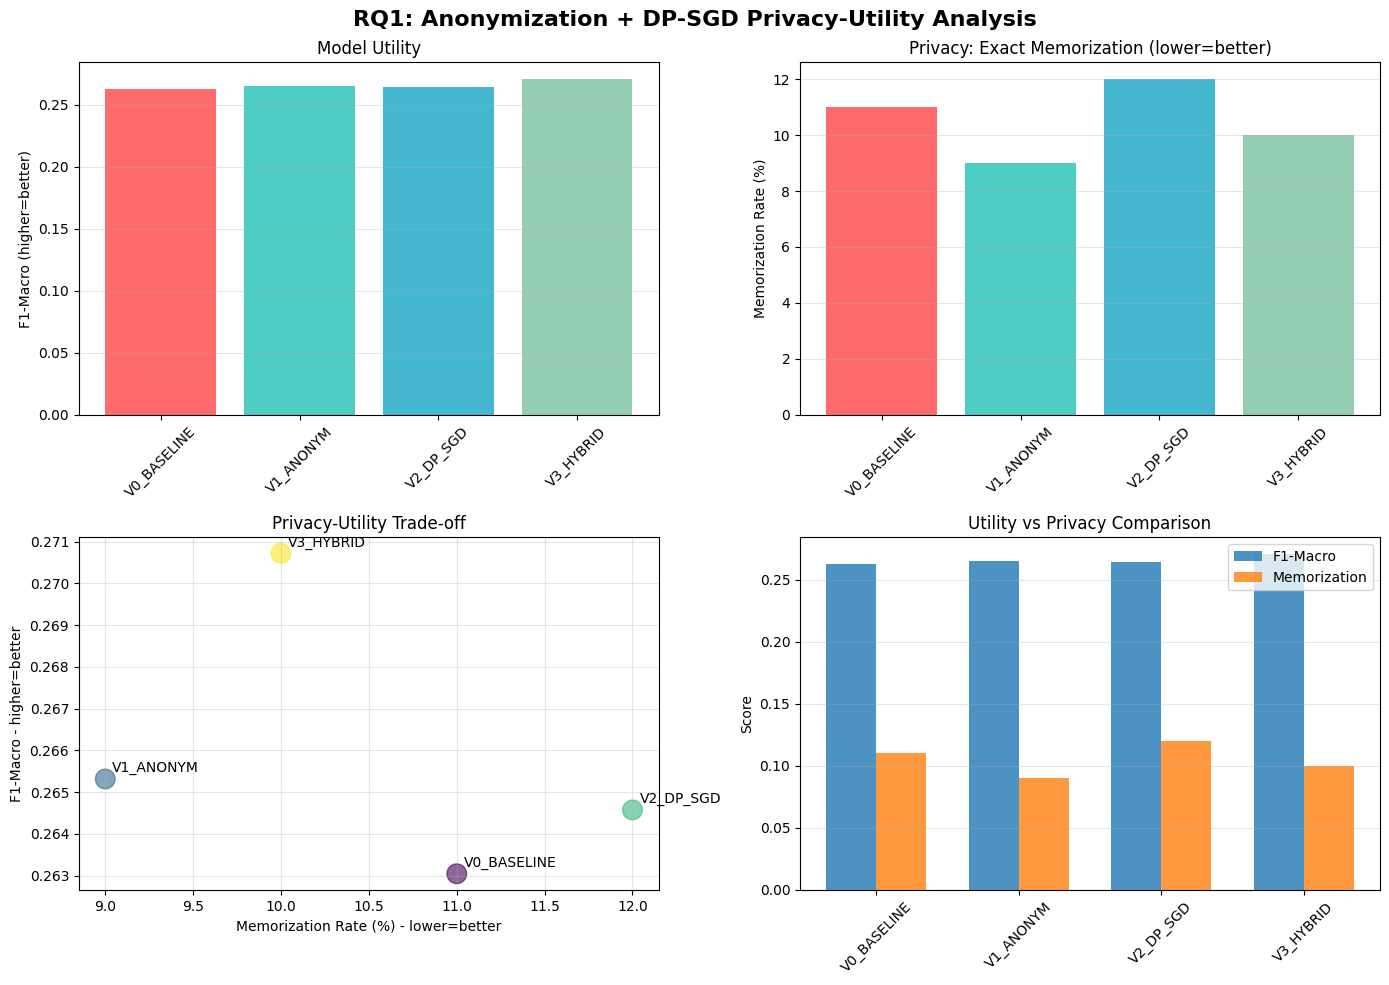

Visualization saved


In [17]:
# Combine results
final_results = eval_df.merge(privacy_df, on='variant')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RQ1: Anonymization + DP-SGD Privacy-Utility Analysis', fontsize=16, fontweight='bold')

# F1-Macro comparison
axes[0, 0].bar(final_results['variant'], final_results['f1_macro'], color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
axes[0, 0].set_ylabel('F1-Macro (higher=better)')
axes[0, 0].set_title('Model Utility')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Memorization rate (lower=better privacy)
axes[0, 1].bar(final_results['variant'], final_results['memorization_rate']*100, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
axes[0, 1].set_ylabel('Memorization Rate (%)')
axes[0, 1].set_title('Privacy: Exact Memorization (lower=better)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Privacy-Utility Trade-off
axes[1, 0].scatter(final_results['memorization_rate']*100, final_results['f1_macro'], s=200, alpha=0.6, c=range(len(final_results)))
for idx, row in final_results.iterrows():
    axes[1, 0].annotate(row['variant'], (row['memorization_rate']*100, row['f1_macro']), xytext=(5, 5), textcoords='offset points')
axes[1, 0].set_xlabel('Memorization Rate (%) - lower=better')
axes[1, 0].set_ylabel('F1-Macro - higher=better')
axes[1, 0].set_title('Privacy-Utility Trade-off')
axes[1, 0].grid(alpha=0.3)

# All metrics comparison
metrics_to_plot = ['f1_macro', 'memorization_rate']
x = np.arange(len(final_results))
width = 0.35
axes[1, 1].bar(x - width/2, final_results['f1_macro'], width, label='F1-Macro', alpha=0.8)
axes[1, 1].bar(x + width/2, final_results['memorization_rate'], width, label='Memorization', alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(final_results['variant'], rotation=45)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Utility vs Privacy Comparison')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'rq1_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved")